In [23]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Set the path to the file you'd like to load
file_path = "KNNAlgorithmDataset.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "gkalpolukcu/knn-algorithm-dataset",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df.head()

/var/folders/9b/2fjcrmgn6cn8c66zrqxjrw780000gn/T/ipykernel_16219/976993709.py:13: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [26]:
X = df.drop(columns=['id', 'diagnosis', 'Unnamed: 32'], errors='ignore')
y = df['diagnosis']

X_mean = X.mean()
X_std = X.std()
X_scaled = (X - X_mean) / X_std

test_idx = 0
new_point = X_scaled.iloc[test_idx].values
X_train = np.delete(X_scaled.values, test_idx, axis=0)
y_train = y.drop(index=test_idx).values

X_train.shape, y_train.shape


((568, 30), (568,))

In [27]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

In [28]:
class KNearestNeighbors:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X = np.array(X)
        self.y = np.array(y)

    def predict(self, point):
        distances = [euclidean_distance(point, self.X[i]) for i in range(len(self.X))]
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y[i] for i in k_indices]
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]
        

In [29]:
clf = KNearestNeighbors(k=3)
clf.fit(X_train, y_train)

prediction = clf.predict(new_point)
print(f"Predicted: {prediction}, Actual: {y.iloc[test_idx]}")

Predicted: M, Actual: M


In [30]:
def predict_all(X, y, k=3):
    clf = KNearestNeighbors(k=k)
    predictions = []
    for i in range(len(X)):
        X_train = np.delete(X, i, axis=0)
        y_train = np.delete(y, i)
        clf.fit(X_train, y_train)
        predictions.append(clf.predict(X[i]))
    return np.array(predictions)

X_all = X_scaled.values
y_all = y.values
y_pred = predict_all(X_all, y_all, k=3)
accuracy = np.mean(y_pred == y_all)
print(f"Leave-one-out accuracy (k=3): {accuracy:.4f} ({int(accuracy * len(y_all))}/{len(y_all)})")

Leave-one-out accuracy (k=3): 0.9649 (549/569)


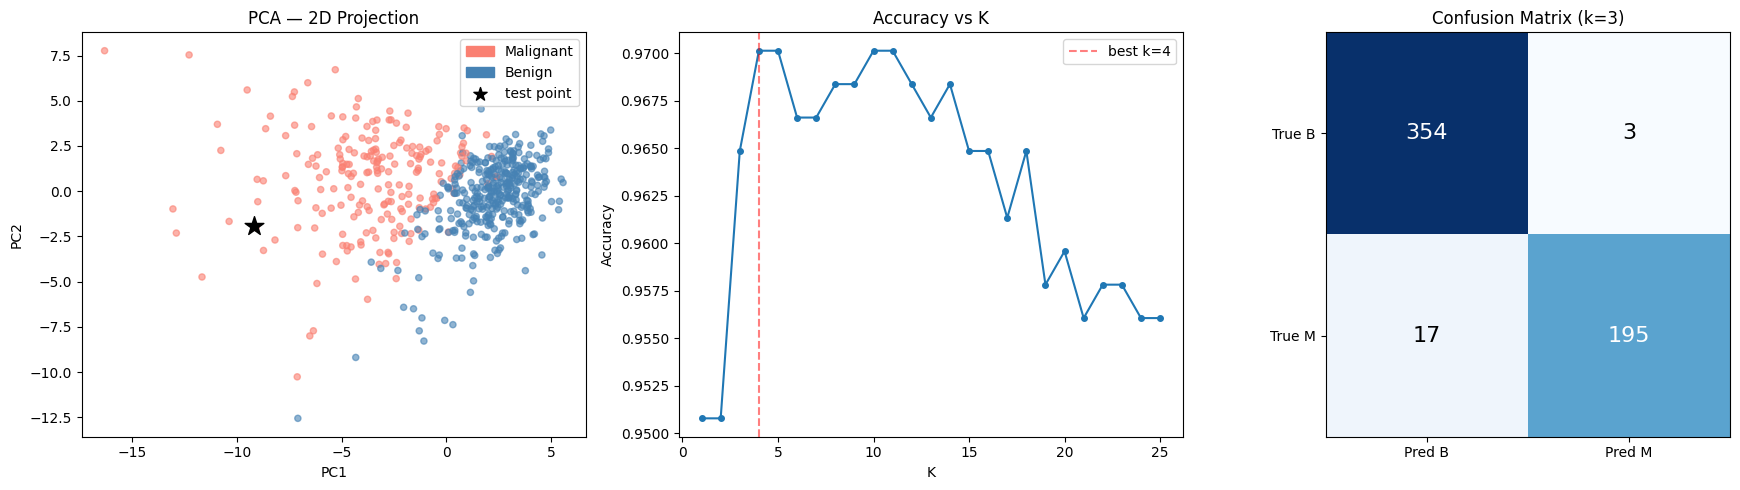

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1 — PCA projection to 2D
cov = np.cov(X_all.T)
eigenvalues, eigenvectors = np.linalg.eigh(cov)
top2 = eigenvectors[:, -2:][:, ::-1]
X_pca = X_all @ top2

colors = np.where(y_all == 'M', 'salmon', 'steelblue')
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.6, s=20)
axes[0].scatter(X_pca[0, 0], X_pca[0, 1], c='black', marker='*', s=200, zorder=5, label='test point')
axes[0].set_title('PCA — 2D Projection')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
import matplotlib.patches as mpatches
axes[0].legend(handles=[
    mpatches.Patch(color='salmon', label='Malignant'),
    mpatches.Patch(color='steelblue', label='Benign'),
    axes[0].scatter([], [], c='black', marker='*', s=100, label='test point')
])

# 2 — Accuracy vs K
k_values = range(1, 26)
accuracies = []
for k in k_values:
    preds = predict_all(X_all, y_all, k=k)
    accuracies.append(np.mean(preds == y_all))

axes[1].plot(k_values, accuracies, marker='o', markersize=4)
axes[1].set_title('Accuracy vs K')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Accuracy')
best_k = k_values[np.argmax(accuracies)]
axes[1].axvline(best_k, color='red', linestyle='--', alpha=0.5, label=f'best k={best_k}')
axes[1].legend()

# 3 — Confusion matrix
tp = np.sum((y_pred == 'M') & (y_all == 'M'))
tn = np.sum((y_pred == 'B') & (y_all == 'B'))
fp = np.sum((y_pred == 'M') & (y_all == 'B'))
fn = np.sum((y_pred == 'B') & (y_all == 'M'))
cm = np.array([[tn, fp], [fn, tp]])

im = axes[2].imshow(cm, cmap='Blues')
axes[2].set_xticks([0, 1])
axes[2].set_yticks([0, 1])
axes[2].set_xticklabels(['Pred B', 'Pred M'])
axes[2].set_yticklabels(['True B', 'True M'])
axes[2].set_title('Confusion Matrix (k=3)')
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, str(cm[i, j]), ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=16)

plt.tight_layout()
plt.show()